In [1]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": -23.6473149,
	"longitude": -46.6643635,
	"start_date": "2013-01-01",
	"end_date": "2019-12-31",
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"],
	"utm_source": "chatgpt.com",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: -23.655536651611328°N -46.7088623046875°E
Elevation: 793.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                            date  temperature_2m  relative_humidity_2m  \
0     2013-01-01 00:00:00+00:00       22.651001             89.586006   
1     2013-01-01 01:00:00+00:00       22.201000             90.384933   
2     2013-01-01 02:00:00+00:00       21.801001             90.357224   
3     2013-01-01 03:00:00+00:00       21.451000             90.053207   
4     2013-01-01 04:00:00+00:00       21.351000             88.658142   
...                         ...             ...                   ...   
61339 2019-12-31 19:00:00+00:00       26.700001             70.325050   
61340 2019-12-31 20:00:00+00:00       25.900000             76.961960   
61341 2019-12-31 21:00:00+00:00       24.000000             79.084686   
61342 2019-12-31 22:00:00+00:00       23.000000             86.899796   
61343 2019-12-31 23:00:00+00:00       22.100000             91.781471   

Arquivo salvo: ../data/open_meteo/openmeteo_historico_2013_2019.csv
                           temperature_2m  relative_humidity_2m  \
time                                                              
2012-12-31 22:00:00-02:00       22.651001             89.586006   
2012-12-31 23:00:00-02:00       22.201000             90.384933   
2013-01-01 00:00:00-02:00       21.801001             90.357224   
2013-01-01 01:00:00-02:00       21.451000             90.053207   
2013-01-01 02:00:00-02:00       21.351000             88.658142   

                           precipitation  wind_speed_10m  
time                                                      
2012-12-31 22:00:00-02:00            0.0        3.976330  
2012-12-31 23:00:00-02:00            0.0        6.489992  
2013-01-01 00:00:00-02:00            0.0        8.404284  
2013-01-01 01:00:00-02:00            0.0        8.759178  
2013-01-01 02:00:00-02:00            0.0        8.654986  
                           temperature_2m  relati

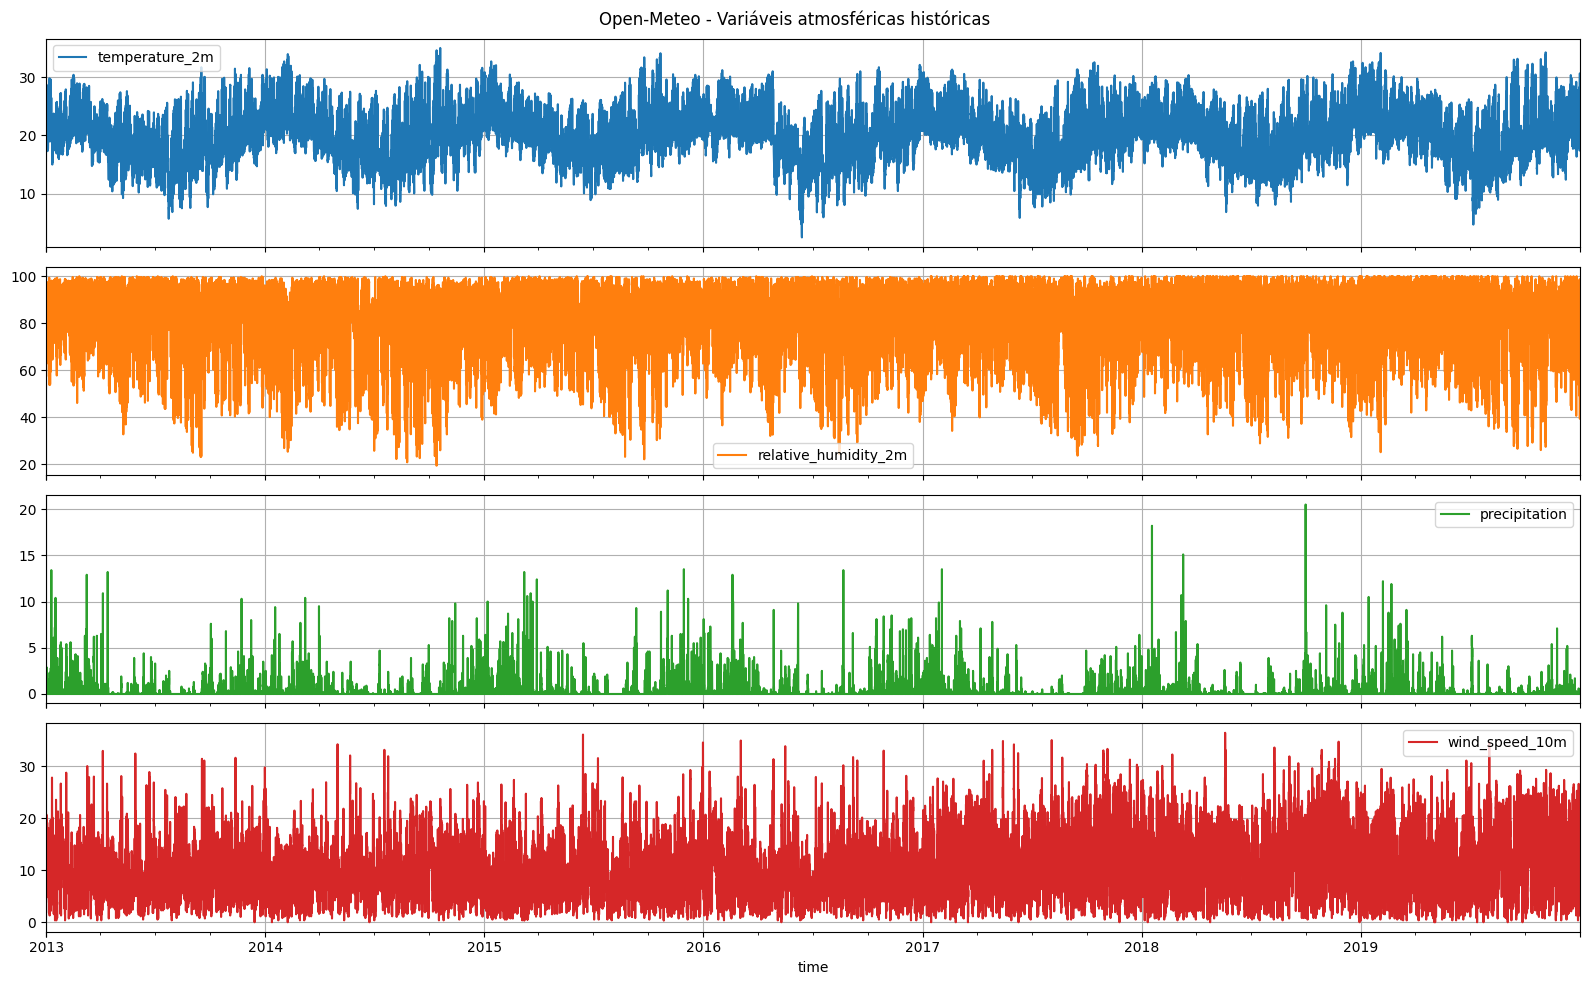

In [2]:
import matplotlib.pyplot as plt

# ===============================
# ORGANIZA DATAFRAME
# ===============================

hourly_dataframe = hourly_dataframe.rename(columns={"date": "time"})

# converter UTC para horário local de São Paulo
hourly_dataframe["time"] = (
    pd.to_datetime(hourly_dataframe["time"], utc=True)
    .dt.tz_convert("America/Sao_Paulo")
)

hourly_dataframe = hourly_dataframe.set_index("time")
hourly_dataframe = hourly_dataframe.sort_index()

# ===============================
# SALVAR CSV
# ===============================

arquivo_saida = "../data/open_meteo/openmeteo_historico_2013_2019.csv"

hourly_dataframe.to_csv(
    arquivo_saida,
    encoding="utf-8"
)

print(f"Arquivo salvo: {arquivo_saida}")
print(hourly_dataframe.head())
print(hourly_dataframe.tail())

# ===============================
# PLOTAR TODAS AS VARIÁVEIS
# ===============================

hourly_dataframe.plot(
    figsize=(16, 10),
    subplots=True,
    sharex=True,
    grid=True,
    title="Open-Meteo - Variáveis atmosféricas históricas"
)

plt.tight_layout()
plt.show()

### Previsão

In [3]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": -23.6473149,
	"longitude": -46.6643635,
	"hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation_probability"],
	"forecast_days": 1,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["precipitation_probability"] = hourly_precipitation_probability

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: -23.655536651611328°N -46.7088623046875°E
Elevation: 793.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                         date  temperature_2m  relative_humidity_2m  \
0  2026-06-09 00:00:00+00:00       15.750000             77.882668   
1  2026-06-09 01:00:00+00:00       14.900000             80.105537   
2  2026-06-09 02:00:00+00:00       14.250000             83.262062   
3  2026-06-09 03:00:00+00:00       13.600000             86.561256   
4  2026-06-09 04:00:00+00:00       13.200000             88.260132   
5  2026-06-09 05:00:00+00:00       12.900000             88.234177   
6  2026-06-09 06:00:00+00:00       12.850000             85.913681   
7  2026-06-09 07:00:00+00:00       12.550000             85.882904   
8  2026-06-09 08:00:00+00:00       12.250000             86.139755   
9  2026-06-09 09:00:00+00:00       11.900000             86.683632   
10 2026-06-09 10:00:00+00:00       12.050000             84.403610   
11 2026-06-09 11:00:00+00:00       

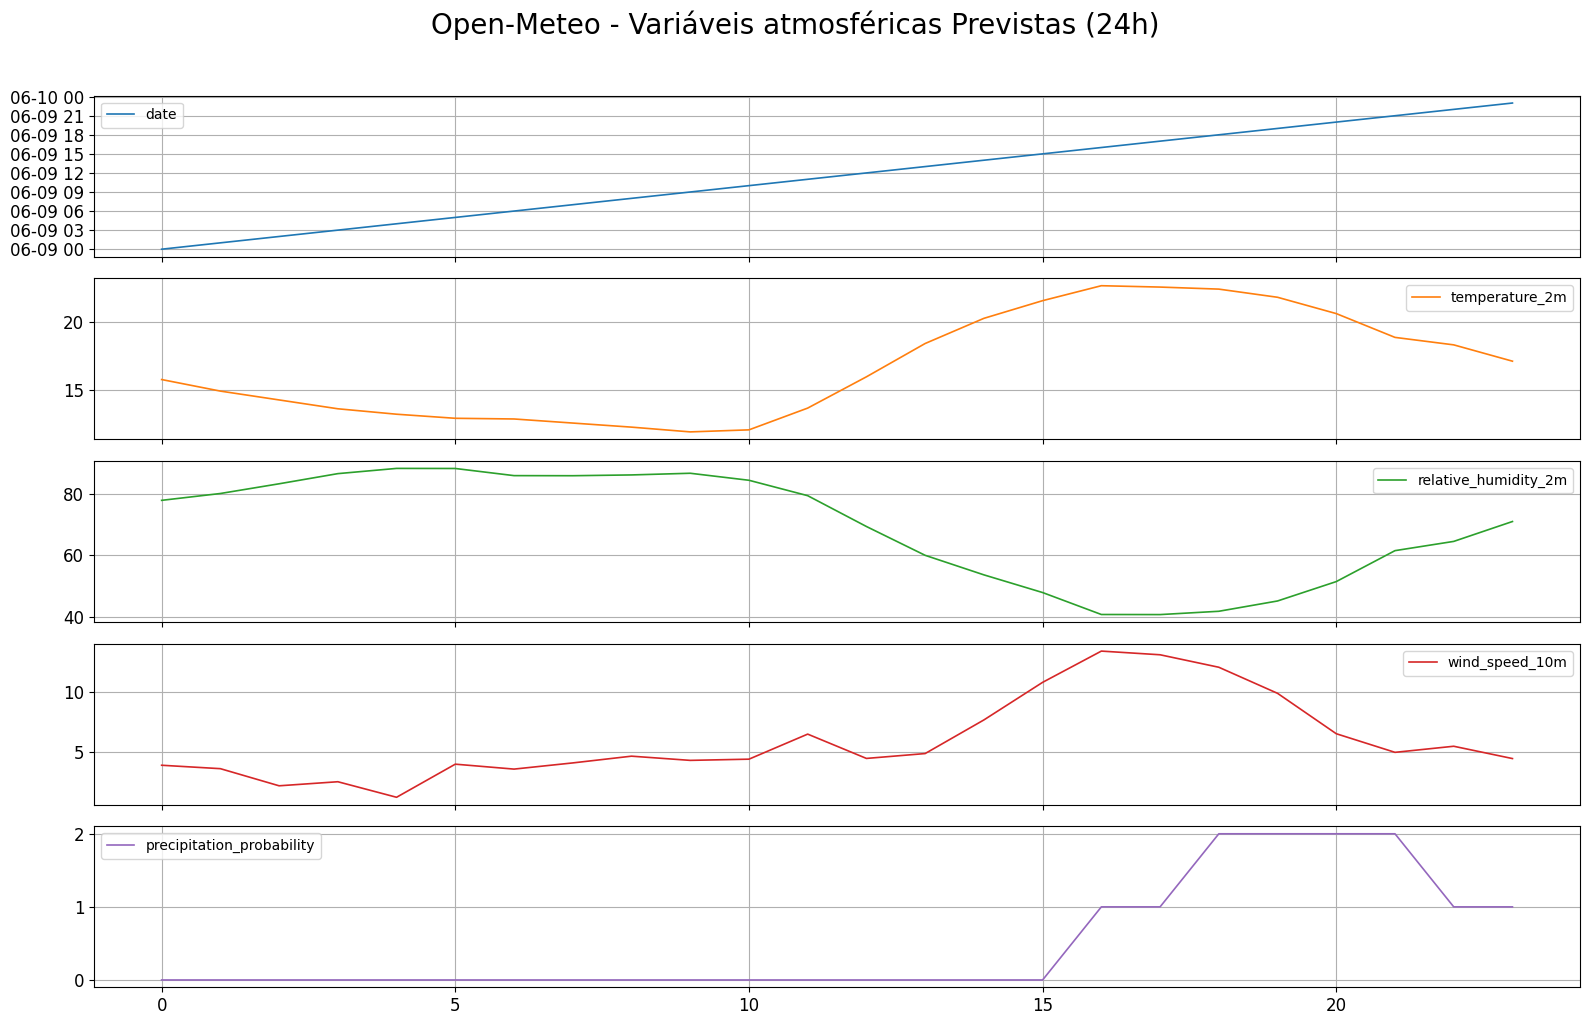

In [4]:
import matplotlib.pyplot as plt

# ==========================================
# PLOT COM FONTES MAIORES
# ==========================================

axes = hourly_dataframe.plot(
    figsize=(16, 10),
    subplots=True,
    sharex=True,
    grid=True,
    linewidth=1.2,
    fontsize=12   # tamanho dos números dos eixos
)

# título geral
plt.suptitle(
    "Open-Meteo - Variáveis atmosféricas Previstas (24h)",
    fontsize=20,
    y=1.02
)

# ajusta títulos e labels de cada subplot
for ax in axes:

    # título de cada variável
    ax.set_title(
        ax.get_title(),
        fontsize=16
    )

    # labels dos eixos
    ax.set_ylabel(
        ax.get_ylabel(),
        fontsize=14
    )

    ax.set_xlabel(
        ax.get_xlabel(),
        fontsize=14
    )

    # tamanho dos ticks
    ax.tick_params(
        axis='both',
        labelsize=12
    )

plt.tight_layout()
plt.show()